In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikitagupta1812/titanic-mixed-dataset/mixed_titanic_like_dataset_500_rows.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/kaggle/input/datasets/nikitagupta1812/titanic-mixed-dataset/mixed_titanic_like_dataset_500_rows.csv')
df


,PassengerId,Pclass,Sex,Age,Fare,Cabin,Ticket,Deck,number,Survived
0,1,3,female,51,38.52,Y113,C.A. 523608,B,4,0
1,2,1,female,19,237.81,Z45,236046,F,4,0
2,3,3,male,21,114.27,F147,SOTON/OQ 267146,G,6,0
3,4,3,female,5,50.36,W91,C.A. 327694,D,4,1
4,5,1,female,42,137.77,P8,STON/O2. 862266,A,2,0
...,...,...,...,...,...,...,...,...,...,...
495,496,2,male,12,60.68,N65,98819,G,3,0
496,497,2,female,19,22.93,N65,LINE 943643,G,3,0
497,498,1,female,44,152.84,T109,391390,F,4,1
498,499,2,male,59,168.71,J22,STON/O2. 221195,B,4,0


In [4]:
df['number'].unique()

array(['4', '6', '2', 'A', '3', '5', '1'], dtype=object)

Text(0.5, 1.0, 'Passengers travelling with')

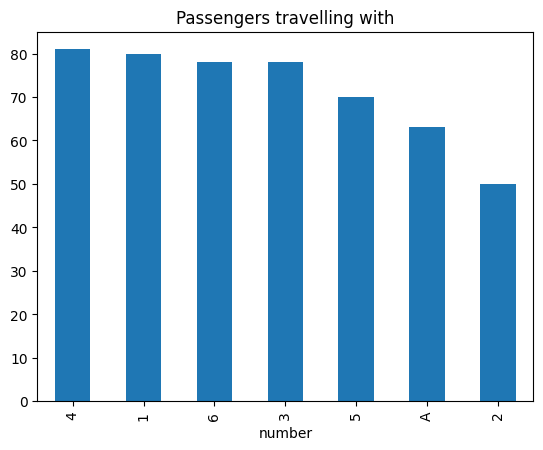

In [5]:
fig = df['number'].value_counts().plot.bar()
fig.set_title("Passengers travelling with")


## EXTRACTING NUMERICAL PART

In [6]:
df['number_numerical'] = pd.to_numeric(df["number"],errors='coerce',downcast='integer')


## EXTRACT CATEGORICAL PART 

In [7]:
df['number_categorical'] = np.where(df['number_numerical'].isnull,df['number'],np.nan)
df.head()

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Ticket,Deck,number,Survived,number_numerical,number_categorical
0,1,3,female,51,38.52,Y113,C.A. 523608,B,4,0,4.0,4
1,2,1,female,19,237.81,Z45,236046,F,4,0,4.0,4
2,3,3,male,21,114.27,F147,SOTON/OQ 267146,G,6,0,6.0,6
3,4,3,female,5,50.36,W91,C.A. 327694,D,4,1,4.0,4
4,5,1,female,42,137.77,P8,STON/O2. 862266,A,2,0,2.0,2


In [8]:
df['number_categorical'] = np.where(df['number_numerical'].isnull,df['number'],np.nan)
df.tail()

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Ticket,Deck,number,Survived,number_numerical,number_categorical
495,496,2,male,12,60.68,N65,98819,G,3,0,3.0,3
496,497,2,female,19,22.93,N65,LINE 943643,G,3,0,3.0,3
497,498,1,female,44,152.84,T109,391390,F,4,1,4.0,4
498,499,2,male,59,168.71,J22,STON/O2. 221195,B,4,0,4.0,4
499,500,3,female,49,156.78,M5,STON/O2. 809057,B,A,1,NaN,A


In [9]:
df['Cabin'].unique()

array(['Y113', 'Z45', 'F147', 'W91', 'P8', 'D149', 'Z144', 'D123', 'D80',
       'I59', 'Y57', 'X135', 'C29', 'E27', 'Z55', 'J101', 'W113', 'Y23',
       'X59', 'A58', 'O17', 'X113', 'E19', 'E149', 'M93', 'O46', 'V58',
       'K74', 'T129', 'B19', 'Z27', 'Z3', 'H89', 'R114', 'C23', 'F48',
       'P5', 'H104', 'D19', 'A95', 'T12', 'C80', 'E24', 'H28', 'J121',
       'M106', 'G73', 'Y4', 'Y82', 'E133', 'X66', 'J136', 'R101', 'O12',
       'K68', 'I142', 'B80', 'T143', 'W145', 'T109', 'A6', 'C102', 'B69',
       'N45', 'S51', 'H122', 'Z121', 'I53', 'K5', 'E146', 'B126', 'Y75',
       'Z101', 'V45', 'S95', 'U71', 'A73', 'L88', 'S71', 'N13', 'G45',
       'G106', 'I80', 'E147', 'K56', 'R137', 'W112', 'P136', 'H14',
       'U106', 'Q119', 'W51', 'R146', 'G14', 'S14', 'L85', 'F110', 'Y15',
       'Z128', 'F78', 'B46', 'K134', 'V105', 'R53', 'S46', 'A22', 'N89',
       'M122', 'V145', 'D58', 'T120', 'H127', 'F2', 'S23', 'N102', 'Y121',
       'N65', 'M5', 'H65', 'G125', 'P22', 'U85', 'D34', 'T

In [10]:
df['Ticket'].unique()

array(['C.A. 523608', '236046', 'SOTON/OQ 267146', 'C.A. 327694',
       'STON/O2. 862266', 'SOTON/OQ 500666', 'STON/O2. 27550',
       'PC 956751', 'SOTON/OQ 487458', 'SOTON/OQ 181779', 'LINE 11794',
       'LINE 76794', '650233', 'LINE 533577', '856751', 'PC 82396',
       'LINE 763580', '906029', 'LINE 261233', 'C.A. 96400',
       'STON/O2. 852663', 'A/5 713347', 'STON/O2. 755870', 'LINE 834794',
       '426008', '788617', '456319', 'SOTON/OQ 89924', 'LINE 218003',
       'SOTON/OQ 663609', 'STON/O2. 883451', 'PC 549128',
       'STON/O2. 918121', 'A/5 688500', '53063', 'C.A. 500974',
       'A/5 544248', 'C.A. 819098', 'A/5 597215', '991051', '931787',
       'STON/O2. 685408', 'LINE 953715', '84612', 'LINE 283357',
       'A/5 742292', 'STON/O2. 615678', 'A/5 669195', 'PC 849099',
       'STON/O2. 583582', 'STON/O2. 457977', 'A/5 39696', 'A/5 627629',
       'STON/O2. 902946', 'LINE 508075', '112115', 'PC 394494',
       'C.A. 875980', 'STON/O2. 401366', 'PC 380961', '399622',
  

In [11]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)') ## Captures numerical part
df['cabin_cat'] = df['Cabin'].str[0] ## Captures the first letter 



<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17/3182230311.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num'] = df['Cabin'].str.extract('(\d+)') ## Captures numerical part


In [12]:
df.tail()

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Ticket,Deck,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
495,496,2,male,12,60.68,N65,98819,G,3,0,3.0,3,65,N
496,497,2,female,19,22.93,N65,LINE 943643,G,3,0,3.0,3,65,N
497,498,1,female,44,152.84,T109,391390,F,4,1,4.0,4,109,T
498,499,2,male,59,168.71,J22,STON/O2. 221195,B,4,0,4.0,4,22,J
499,500,3,female,49,156.78,M5,STON/O2. 809057,B,A,1,NaN,A,5,M


In [13]:
## Extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                errors= 'coerce',
                                downcast='integer')


## Extract the first part of Ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(),np.nan,
df['ticket_cat'])
df.head(20)

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Ticket,Deck,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,1,3,female,51,38.52,Y113,C.A. 523608,B,4,0,4.0,4,113,Y,523608,C.A.
1,2,1,female,19,237.81,Z45,236046,F,4,0,4.0,4,45,Z,236046,NaN
2,3,3,male,21,114.27,F147,SOTON/OQ 267146,G,6,0,6.0,6,147,F,267146,SOTON/OQ
3,4,3,female,5,50.36,W91,C.A. 327694,D,4,1,4.0,4,91,W,327694,C.A.
4,5,1,female,42,137.77,P8,STON/O2. 862266,A,2,0,2.0,2,8,P,862266,STON/O2.
5,6,1,male,61,218.87,D149,SOTON/OQ 500666,G,A,1,NaN,A,149,D,500666,SOTON/OQ
6,7,3,female,22,184.40,Z144,STON/O2. 27550,A,3,1,3.0,3,144,Z,27550,STON/O2.
7,8,2,male,21,202.61,D123,PC 956751,A,5,1,5.0,5,123,D,956751,PC
8,9,3,male,70,166.40,D80,SOTON/OQ 487458,B,3,0,3.0,3,80,D,487458,SOTON/OQ
9,10,3,female,1,174.61,I59,SOTON/OQ 181779,G,3,0,3.0,3,59,I,181779,SOTON/OQ


<Axes: xlabel='cabin_cat'>

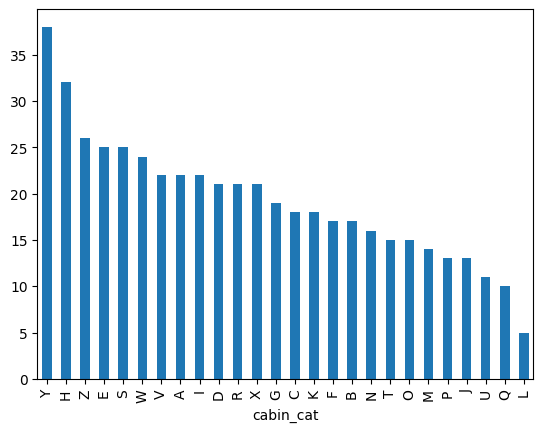

In [14]:

    df['cabin_cat'].value_counts().plot(kind='bar')


In [15]:
## Extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                errors='coerce',
                                downcast= 'integer')

## Extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(),np.nan,
                           df['ticket_cat'])
df.head(20)

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Ticket,Deck,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,1,3,female,51,38.52,Y113,C.A. 523608,B,4,0,4.0,4,113,Y,523608,C.A.
1,2,1,female,19,237.81,Z45,236046,F,4,0,4.0,4,45,Z,236046,NaN
2,3,3,male,21,114.27,F147,SOTON/OQ 267146,G,6,0,6.0,6,147,F,267146,SOTON/OQ
3,4,3,female,5,50.36,W91,C.A. 327694,D,4,1,4.0,4,91,W,327694,C.A.
4,5,1,female,42,137.77,P8,STON/O2. 862266,A,2,0,2.0,2,8,P,862266,STON/O2.
5,6,1,male,61,218.87,D149,SOTON/OQ 500666,G,A,1,NaN,A,149,D,500666,SOTON/OQ
6,7,3,female,22,184.40,Z144,STON/O2. 27550,A,3,1,3.0,3,144,Z,27550,STON/O2.
7,8,2,male,21,202.61,D123,PC 956751,A,5,1,5.0,5,123,D,956751,PC
8,9,3,male,70,166.40,D80,SOTON/OQ 487458,B,3,0,3.0,3,80,D,487458,SOTON/OQ
9,10,3,female,1,174.61,I59,SOTON/OQ 181779,G,3,0,3.0,3,59,I,181779,SOTON/OQ


<Axes: xlabel='ticket_cat'>

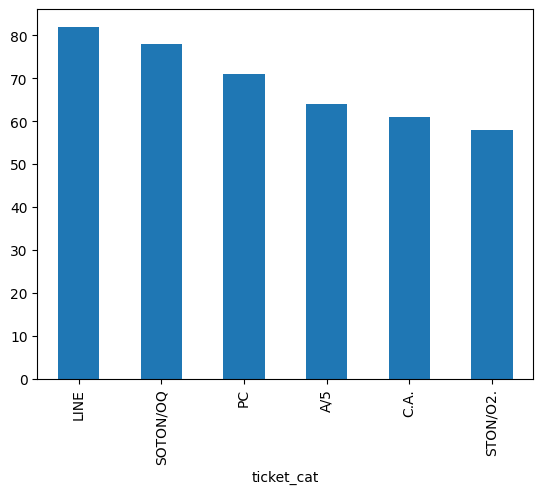

In [16]:
df['ticket_cat'].value_counts().plot(kind='bar')